#데이터 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('yahoo_1.csv',header=None, names=['value']) #파일란에 야후데이터 추가
series = df[df.columns[0]].values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   1420 non-null   float64
dtypes: float64(1)
memory usage: 11.2 KB


#주기 파악

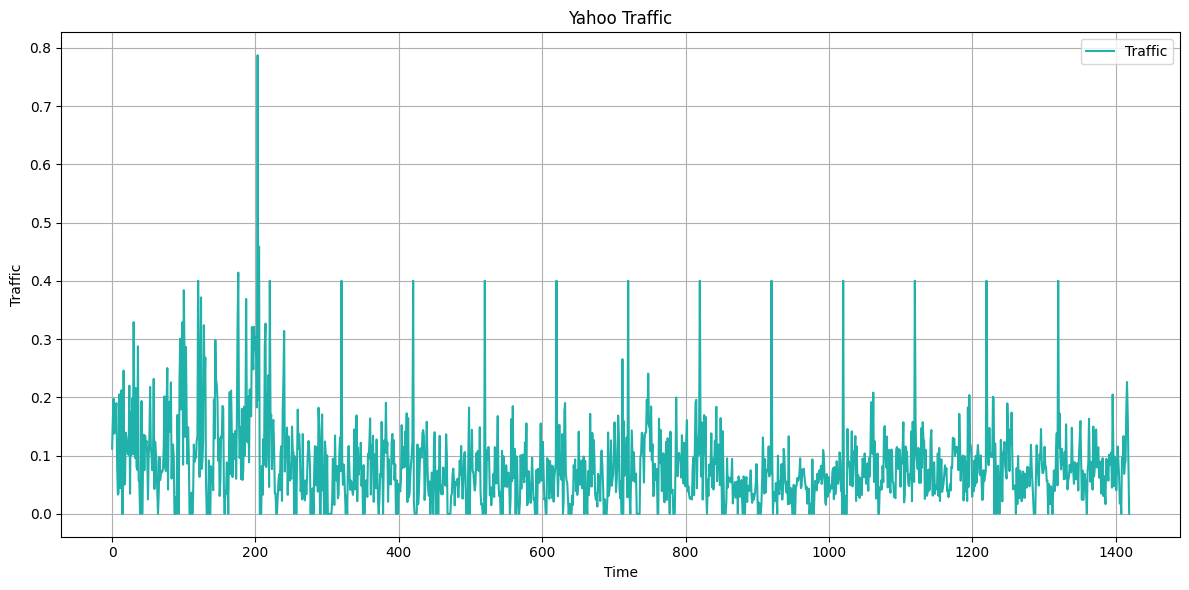

In [ ]:
#기본 시각화
column_name = df.columns[0]
series = df[column_name]

plt.figure(figsize=(12, 6))
plt.plot(series, label='Traffic', color = 'LightSeaGreen')
plt.title('Yahoo Traffic')
plt.xlabel('Time')
plt.ylabel('Traffic')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

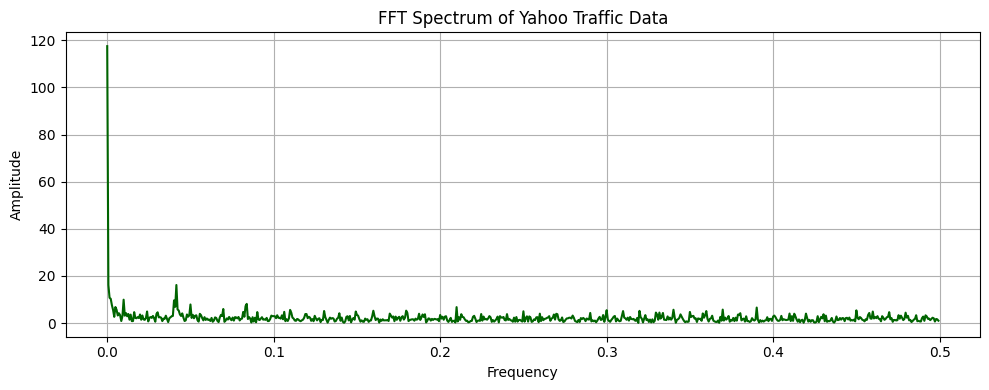

Dominant Frequency: 0.0007042253521126761
Estimated Period: 1420.0


In [ ]:
# FFT
from scipy.fft import fft

# 시계열 데이터 추출 (첫 번째 열 기준)
series = df[df.columns[0]].values
n = len(series)

# FFT 적용
fft_vals = fft(series)
freqs = np.fft.fftfreq(n)  # 주파수 배열

# 양수 주파수만 추출 (대칭 제거)
positive_freqs = freqs[:n//2]
amplitudes = np.abs(fft_vals)[:n//2]

# 시각화
plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, amplitudes, color='darkgreen')
plt.title("FFT Spectrum of Yahoo Traffic Data")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# 지배적인 주파수 찾기 (0은 제외)
peak_idx = np.argmax(amplitudes[1:]) + 1
dominant_frequency = positive_freqs[peak_idx]
dominant_period = 1 / dominant_frequency if dominant_frequency != 0 else None

# 결과 출력
print("Dominant Frequency:", dominant_frequency)
print("Estimated Period:", dominant_period)

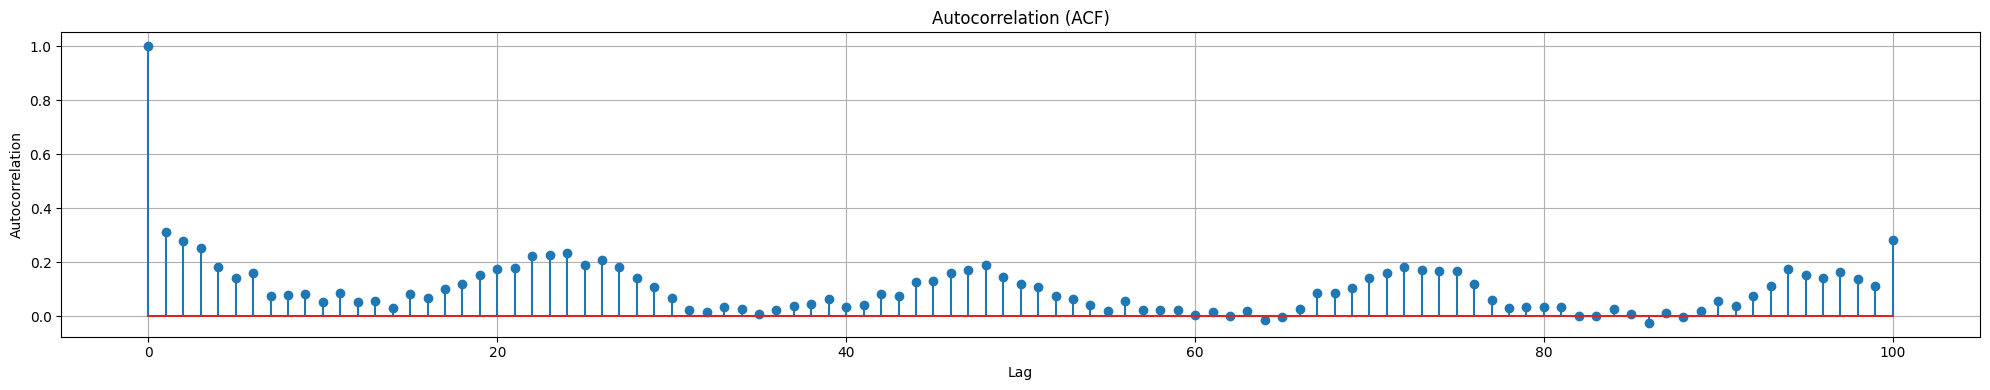

ACF at lag 1: 0.311
ACF at lag 100: 0.282
ACF at lag 2: 0.278
ACF at lag 3: 0.251
ACF at lag 24: 0.235
ACF at lag 23: 0.226
ACF at lag 22: 0.223
ACF at lag 26: 0.209
ACF at lag 48: 0.191
ACF at lag 25: 0.190


In [ ]:
#Autocorrelation
from statsmodels.tsa.stattools import acf

# 시계열 데이터 추출
series = df[df.columns[0]].values

# ACF 계산 (최대 100 lag까지)
acf_vals = acf(series, nlags=100)

# 시각화
plt.figure(figsize=(20, 4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.title("Autocorrelation (ACF)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.tight_layout()
plt.show()

# 주요 lag 상위 3개 출력 (lag=0 제외)
top_lags = sorted(range(1, len(acf_vals)), key=lambda i: acf_vals[i], reverse=True)[:10]
for lag in top_lags:
    print(f"ACF at lag {lag}: {acf_vals[lag]:.3f}")

*이탤릭체 텍스트*# 새 *섹션*

# 이상치 탐색

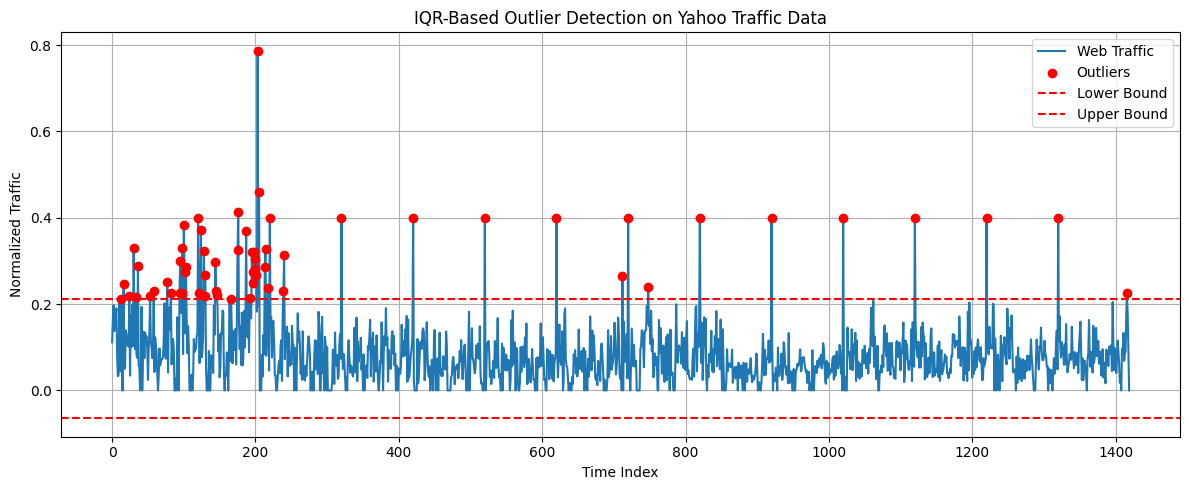

Detected Outliers: 60


In [ ]:
series = df[df.columns[0]].values

# IQR 계산
Q1 = np.percentile(series, 25)
Q3 = np.percentile(series, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 인덱스 추출
outlier_indices = np.where((series < lower_bound) | (series > upper_bound))[0]

# 시각화
plt.figure(figsize=(12, 5))
plt.plot(series, label="Web Traffic")
plt.scatter(outlier_indices, series[outlier_indices], color='red', label="Outliers", zorder=5)
plt.axhline(lower_bound, color='red', linestyle='--', label="Lower Bound")
plt.axhline(upper_bound, color='red', linestyle='--', label="Upper Bound")
plt.title("IQR-Based Outlier Detection on Yahoo Traffic Data")
plt.xlabel("Time Index")
plt.ylabel("Normalized Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 이상치 개수 출력
print(f"Detected Outliers: {len(outlier_indices)}")

#전처리

In [ ]:
# 주기 기반 보간

# 0.4 → NaN 처리
masked_series = np.where(series == 0.4, np.nan, series)

# DataFrame으로 감싸기
df_season = pd.DataFrame({"traffic": masked_series})

# 주기 기반 보간 (lag=24)
period = 24
for i in range(period, len(df_season)):
    if np.isnan(df_season.loc[i, "traffic"]):
        df_season.loc[i, "traffic"] = df_season.loc[i - period, "traffic"]
masked_series = df_season["traffic"].values

In [ ]:
#초반 과하게 높은 구간을 찾기 위한 구간별 평균

# 1. 24시간 단위로 나누기 (pandas Series로 감싸면 mean()에서 NaN 자동 무시)
window = 24
chunks = [pd.Series(masked_series[i:i+window]) for i in range(0, len(masked_series), window)]

# 2. 각 청크별 평균 계산
chunk_stats = pd.DataFrame([
    {
        "chunk": i,
        "mean": chunk.mean()  # NaN 제외 자동 처리됨
    }
    for i, chunk in enumerate(chunks)
])

# 5. 전체 평균 (NaN 제외)
global_mean = np.nanmean(masked_series)

# 6. 시각화
plt.figure(figsize=(12, 6))
plt.bar(chunk_stats["chunk"], chunk_stats["mean"], label="Chunk Mean", color='orange')
plt.axhline(global_mean, color='blue', linestyle='--', label=f"Overall Mean = {global_mean:.4f}")
plt.title("Mean per 24-hour(Excluding 0.4 as NaN)")
plt.xlabel("24-hour Chunk Index")
plt.ylabel("Mean Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'masked_series' is not defined

In [ ]:
# 이전 작업으로 찾은 전반적으로 과도하게 높은 수치를 보이는 초반 11일의 데이터를 제거
slided_series = masked_series[264:]
not_imputated_slided_series = series[264:]

#모델 학습(하이퍼파라미터 X, 피처 기본)


Test MSE: 0.0019837381842140608
Test RMSE: 0.04453917583671773


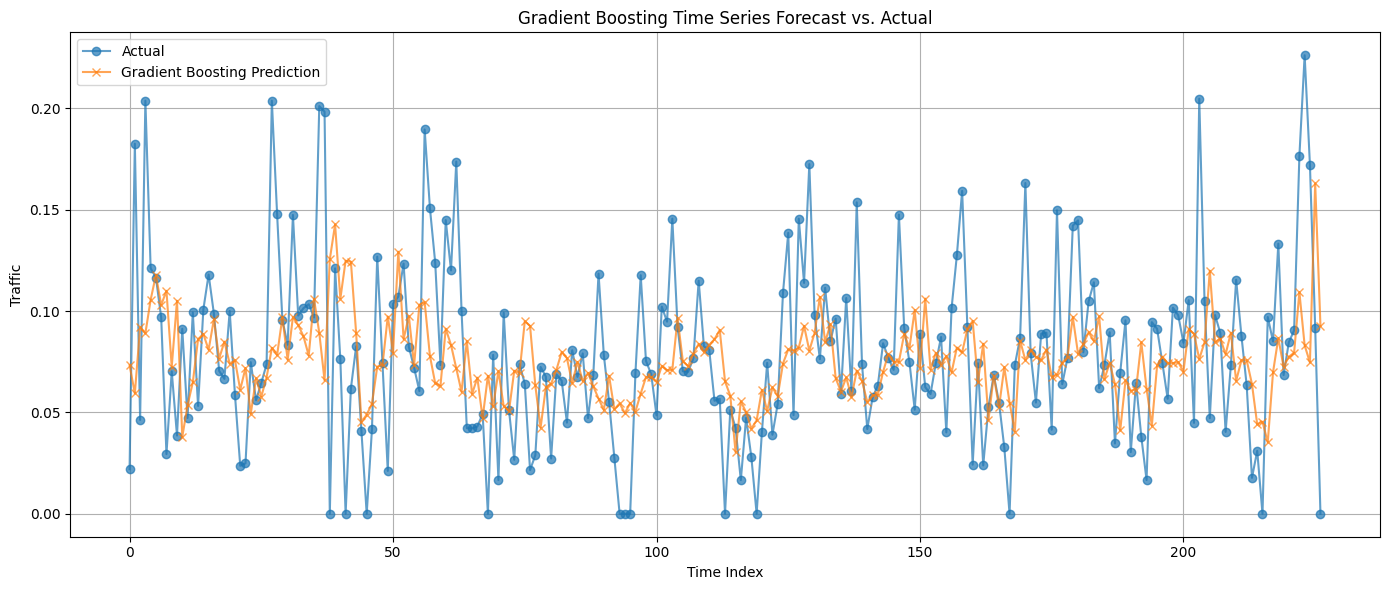

In [ ]:
# GradientBoosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# (1) 윈도우 크기 정의
window = 24

# (2) 입력(X), 출력(y) 생성 (RandomForest 때와 동일)
X, y = [], []
for i in range(window, len(slided_series)):
    X.append(slided_series[i-window:i])
    y.append(slided_series[i])

X = np.array(X)
y = np.array(y)

# (3) 학습/테스트 분할
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# (4) 모델 학습 및 예측
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# (5) 성능 평가 (MSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Gradient Boosting Prediction", marker='x', alpha=0.7)
plt.title("Gradient Boosting Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Test MSE: 0.0018059004920109802
Test RMSE: 0.04249588794237603
평균 절대 오차 (MAE): 0.03173005113004405


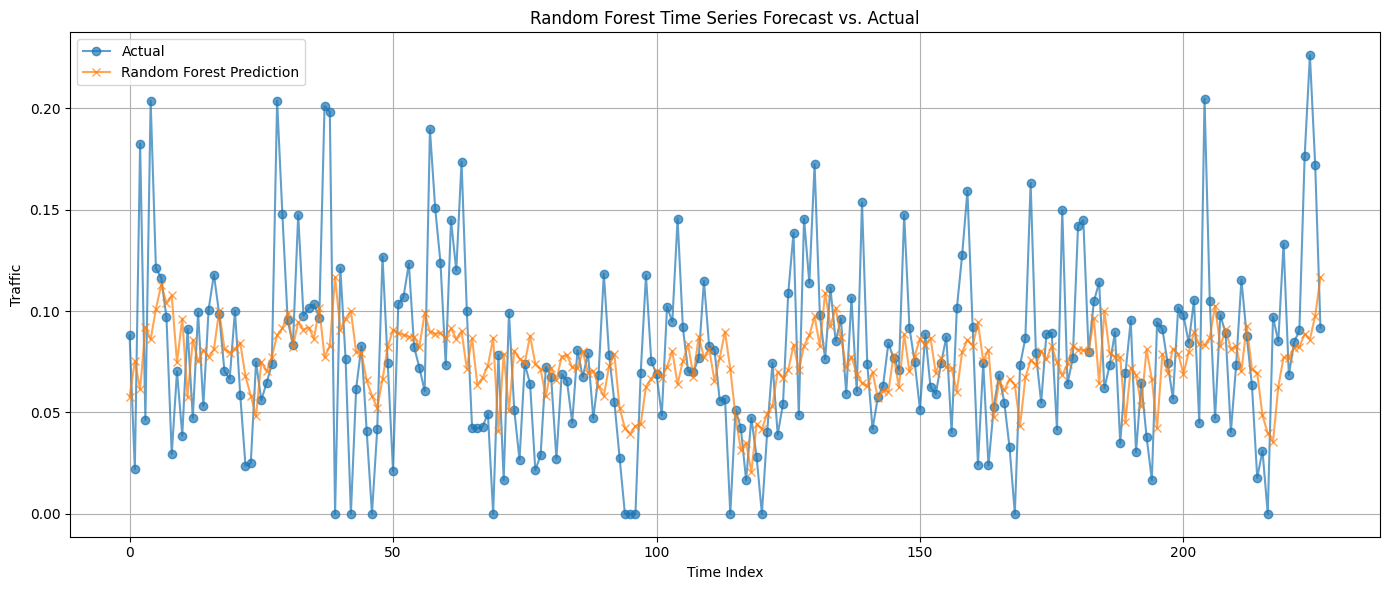

In [ ]:
# RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# window size
window = 24
X = []
y = []

for i in range(window, len(slided_series) - 1):
    X.append(slided_series[i-window:i])
    y.append(slided_series[i])

X = np.array(X)
y = np.array(y)

# 데이터 분리 (예: 80% 학습, 20% 테스트)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("평균 절대 오차 (MAE):", mae)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Random Forest Prediction", marker='x', alpha=0.7)
plt.title("Random Forest Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-9-1896073888.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "ds": pd.date_range("2023-01-01", periods=len(slided_series), freq="H"),
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpooy9wp2u/nddaj3q9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpooy9wp2u/4uptk6i3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12457', 'data', 'file=/tmp/tmpooy9wp2u/nddaj3q9.json', 'init=/tmp/tmpooy9wp2u/4uptk6i3.json', 'output', 'file=/tmp/tmpooy9wp2u/prophet_modela29fp_eb/prophet_model-20250619073226.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:32:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:32:26 - cmdstanpy - INF

Test MSE (Prophet): 0.0016130297391119324
Test RMSE (Prophet): 0.04016254149219061
평균 절대 오차 (MAE): 0.030433361605813884


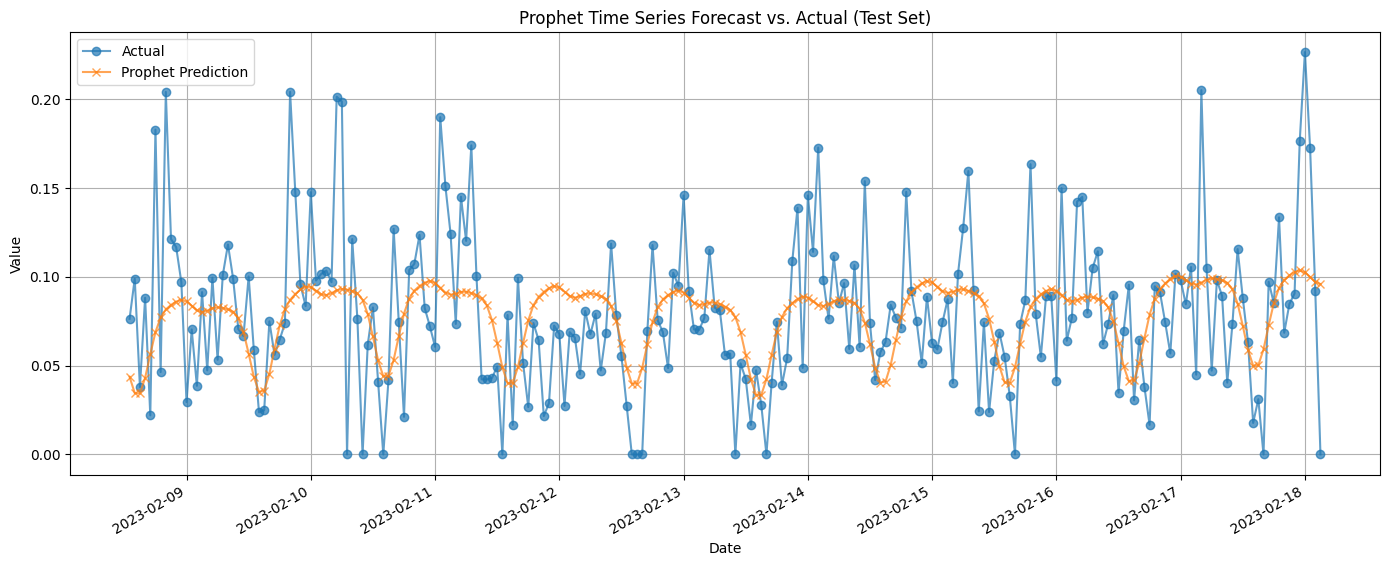

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


# 1. 시계열 준비 (예: slided_series 사용, 길이에 맞게 타임스탬프 생성)
df_prophet = pd.DataFrame({
    "ds": pd.date_range("2023-01-01", periods=len(slided_series), freq="H"),
    "y": slided_series
})

# 2. train/test 분리 (예: 마지막 48개는 test)
test_size = int(len(df_prophet) * 0.2)
df_train = df_prophet.iloc[:-test_size]
df_test = df_prophet.iloc[-test_size:]

# 3. Prophet 모델 학습
model = Prophet(daily_seasonality=True)
model.fit(df_train)

# 4. 미래 예측 (test 구간만큼 확장)
future = model.make_future_dataframe(periods=test_size, freq="H")
forecast = model.predict(future)

# 5. 예측값 중 test구간 추출
# X축으로 사용할 날짜/시간 정보도 함께 준비합니다.
y_test_pred = forecast["yhat"].iloc[-test_size:]
y_test_true = df_test["y"] # reset_index() 없이 원본 시간 인덱스 유지
x_axis_dates = df_test["ds"]

# 6. 평가 (RMSE, MSE) - 이 부분은 동일
mse = mean_squared_error(y_test_true, y_test_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test_true, y_test_pred)
print("Test MSE (Prophet):", mse)
print("Test RMSE (Prophet):", rmse)
print("평균 절대 오차 (MAE):", mae)

# 7. 시각화 (수정된 버전)
plt.figure(figsize=(14, 6))

# x축에 날짜 데이터를, y축에 실제값과 예측값을 넣어줍니다.
plt.plot(x_axis_dates, y_test_true, label="Actual", marker='o', alpha=0.7)
plt.plot(x_axis_dates, y_test_pred, label="Prophet Prediction", marker='x', alpha=0.7)

plt.title("Prophet Time Series Forecast vs. Actual (Test Set)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

# x축의 날짜 라벨이 겹치지 않도록 자동 회전
plt.gcf().autofmt_xdate()

plt.show()

#feature값 조정 (하이퍼파라미터 X)

In [ ]:
# 이전 작업으로 찾은 전반적으로 과도하게 높은 수치를 보이는 초반 11일의 데이터를 제거
only_slided_series = series[264:]

In [ ]:
def make_features_with_time(series, window=24, prev100_n=0, samehour_n=0):
    """
    기존 lag 피처에 가상의 시간/요일 피처를 추가합니다.

    series : 시계열 데이터 (1차원 배열)
    window : 최근 window개 값(기본)
    prev100_n : 100, 200, ... 이전의 값 개수
    samehour_n : 24, 48, ... 이전의 값 개수 (동시간 피처)
    """
    X, y = [], []

    # 1. 가상의 시간 인덱스 생성 (데이터 전체 길이에 대해)
    # 임의의 시작 날짜를 월요일 00시로 설정하여 요일 계산을 용이하게 함
    start_date = '2025-01-06 00:00:00'
    time_index = pd.date_range(start=start_date, periods=len(series), freq='H')

    # 기존 로직: 가장 긴 lag 계산
    max_lag = max(
        window,
        100 * prev100_n if prev100_n > 0 else 0,
        24 * samehour_n if samehour_n > 0 else 0
    )

    # 루프 시작점은 동일, -24 부분은 사용자의 기존 로직 유지
    for i in range(max_lag, len(series) - 24):
        # --- 기존 피처 생성 로직 (동일) ---
        base = series[i-window:i]
        prev100_feats = [series[i-100*n] for n in range(1, prev100_n+1)] if prev100_n > 0 else []
        samehour_feats = [series[i-24*n] for n in range(1, samehour_n+1)] if samehour_n > 0 else []

        # 2. 현재 시점(i)의 시간/요일 피처 추출
        current_time = time_index[i]
        hour_feat = [current_time.hour]
        day_of_week_feat = [current_time.dayofweek] # 월요일=0, 일요일=6

        # 3. 모든 피처를 하나로 결합
        features = np.concatenate([
            base,               # 이전 24시간
            prev100_feats,      # 이전 100번째 반복 (100, 200, ...)
            samehour_feats,     # 이전 24벉째 반복 (24, 48, ...)
            hour_feat,          # 시간 피처 추가
            day_of_week_feat    # 요일 피처 추가
        ])

        X.append(features)
        y.append(series[i])

    return np.array(X), np.array(y)

# --- 함수 사용 예시 ---
# series = pd.read_csv('yahoo_1.csv')['value'].values
# X, y = make_features_with_time(series, window=24, prev100_n=1, samehour_n=2)
# print('피처 형태:', X.shape)
# print('첫 번째 샘플의 마지막 두 피처 (시간, 요일):', X[0, -2:])

/tmp/ipython-input-4-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0015615843403040722
Test RMSE: 0.03951688677393593


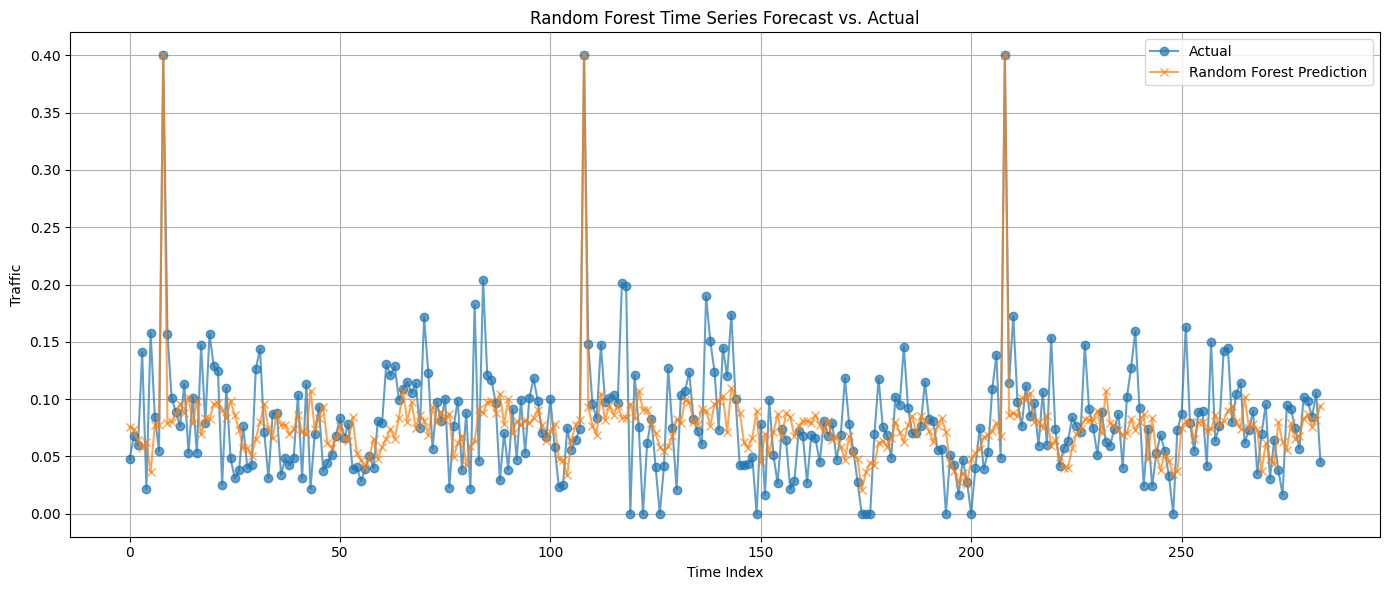

In [ ]:
# RandomForestRegressor를 이용한 테스트 코드
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=1, samehour_n=2) #이전 100의배수와 24의 배수 개수를 조정해가며 테스트(0~5씩 진행한 결과 1, 2가 최적으로 나옴)

# 데이터 분리 (예: 80% 학습, 20% 테스트)
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습
model = RandomForestRegressor(n_estimators = 100, random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Random Forest Prediction", marker='x', alpha=0.7)
plt.title("Random Forest Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GradientBoosting Regressor을 이용한 테스트
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=1, samehour_n=2) #이전 100의배수와 24의 배수 개수를 조정해가며 테스트(0~5씩 진행한 결과 1, 2가 최적으로 나옴)

# 학습/테스트 분할
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습 및 예측
model = GradientBoostingRegressor(n_estimators = 100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 성능 평가 (MSE, RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Gradient Boosting Prediction", marker='x', alpha=0.7)
plt.title("Gradient Boosting Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#파라미터 조정 (피처 조정 후)

In [ ]:
# RandomForestRegressor 최적 하이퍼파라미터 찾기
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. 모델 정의
rf = RandomForestRegressor(random_state=42)

# 2. 하이퍼파라미터 탐색 범위 정의
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': [10, 20, 30, None], # 랜덤 포레스트는 깊은 트리를 허용
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2'] # 또는 1.0
}

# 3. RandomizedSearchCV 객체 생성
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=50, # 50번의 랜덤 조합을 테스트
    cv=3,      # 3-fold 교차 검증
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1  # 모든 CPU 코어 사용
)

# 4. 탐색
# 4.1. window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=1, samehour_n=2)

# 4.2. 데이터 분리 (예: 80% 학습, 20% 테스트)
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 4.3. 탐색 시작
random_search_rf.fit(X_train, y_train)

# 5. 결과 확인
print("\n--- Random Forest Regressor Best Parameters ---")
print("가장 좋은 파라미터:", random_search_rf.best_params_)
print("가장 좋은 점수(MSE):", -random_search_rf.best_score_)

# 6. 가장 좋은 성능을 낸 모델
best_rf_model = random_search_rf.best_estimator_


--- Random Forest Regressor Best Parameters ---
가장 좋은 파라미터: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 14, 'n_estimators': 140}
가장 좋은 점수(MSE): 0.0019086447033400634


In [ ]:
# GradientBoostingRegressor 최적 하이퍼파라미터 찾기
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 1. 모델 정의
gbr = GradientBoostingRegressor(random_state=42)

# 2. 하이퍼파라미터 탐색 범위 정의
param_dist_gbr = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': [3, 5, 7], # 그래디언트 부스팅은 보통 얕은 트리를 사용
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'subsample': uniform(0.7, 0.3), # 0.7 ~ 1.0 사이의 값
    'max_features': ['sqrt', 'log2', None] # None은 모든 피처 사용
}

# 3. RandomizedSearchCV 객체 생성
random_search_gbr = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist_gbr,
    n_iter=50, # 50번의 랜덤 조합을 테스트
    cv=3,      # 3-fold 교차 검증
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1  # 모든 CPU 코어 사용
)

# 4. 탐색
# 4.1. window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=1, samehour_n=2)

# 4.2. 데이터 분리 (예: 80% 학습, 20% 테스트)
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 4.3. 탐색 시작
random_search_gbr.fit(X_train, y_train)

# 5. 결과 확인
print("--- Gradient Boosting Regressor Best Parameters ---")
print("가장 좋은 파라미터:", random_search_gbr.best_params_)
print("가장 좋은 점수(MSE):", -random_search_gbr.best_score_)

# 6. 가장 좋은 성능을 낸 모델
best_gbr_model = random_search_gbr.best_estimator_

<ipython-input-7-957063332>:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0018168825588671393
Test RMSE: 0.04262490538250072


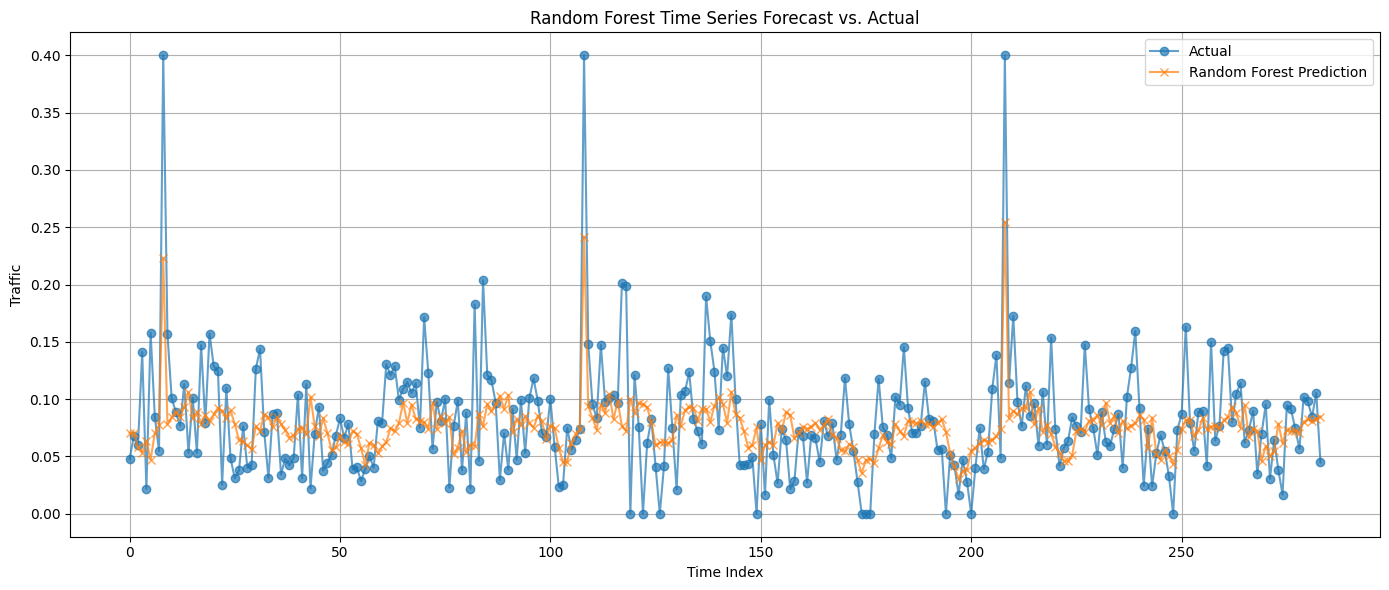

In [ ]:
# RandomForestRegressor 하이퍼 파라미터 적용
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=1, samehour_n=2) #이전 100의배수와 24의 배수 개수를 조정해가며 테스트(0~5씩 진행한 결과 1, 2가 최적으로 나옴)

# 데이터 분리 (예: 80% 학습, 20% 테스트)
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습
model = RandomForestRegressor(max_depth = None, max_features = 'sqrt', min_samples_leaf = 1, min_samples_split = 7, n_estimators = 379, random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Random Forest Prediction", marker='x', alpha=0.7)
plt.title("Random Forest Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-7-957063332>:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0015888082713174647
Test RMSE: 0.03985985789384434


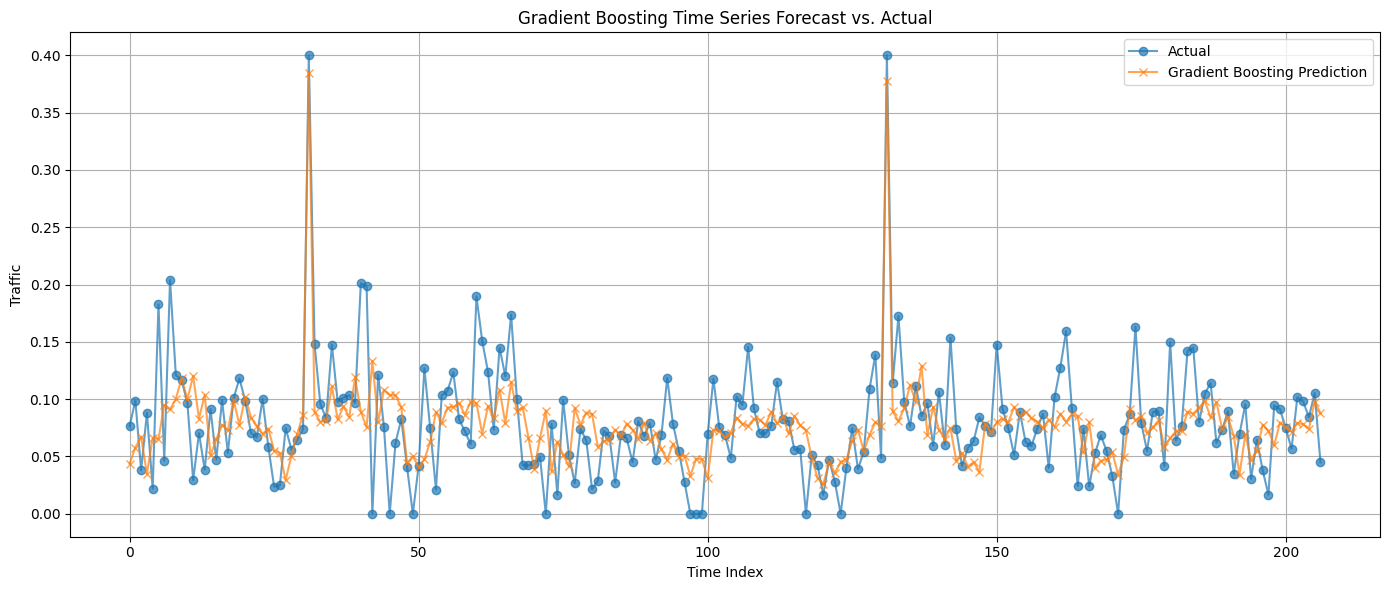

In [ ]:
# GradientBoosting Regressor 하이퍼 파라미터 적용
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=1, samehour_n=2) #이전 100의배수와 24의 배수 개수를 조정해가며 테스트(0~5씩 진행한 결과 1, 2가 최적으로 나옴)

# 학습/테스트 분할
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습 및 예측
model = GradientBoostingRegressor(random_state=42, learning_rate = np.float64(0.03944488920695857), max_depth = 3, max_features = None, min_samples_leaf = 1, min_samples_split = 4, n_estimators = 227, subsample = np.float64(0.8118060601282148))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 성능 평가 (MSE, RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Gradient Boosting Prediction", marker='x', alpha=0.7)
plt.title("Gradient Boosting Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#하이퍼 파라미터 이후 최적 피처값

/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead

0.03952644608105739
3
0
Test MSE: 0.0015950181099877393
Test RMSE: 0.03993767782417675


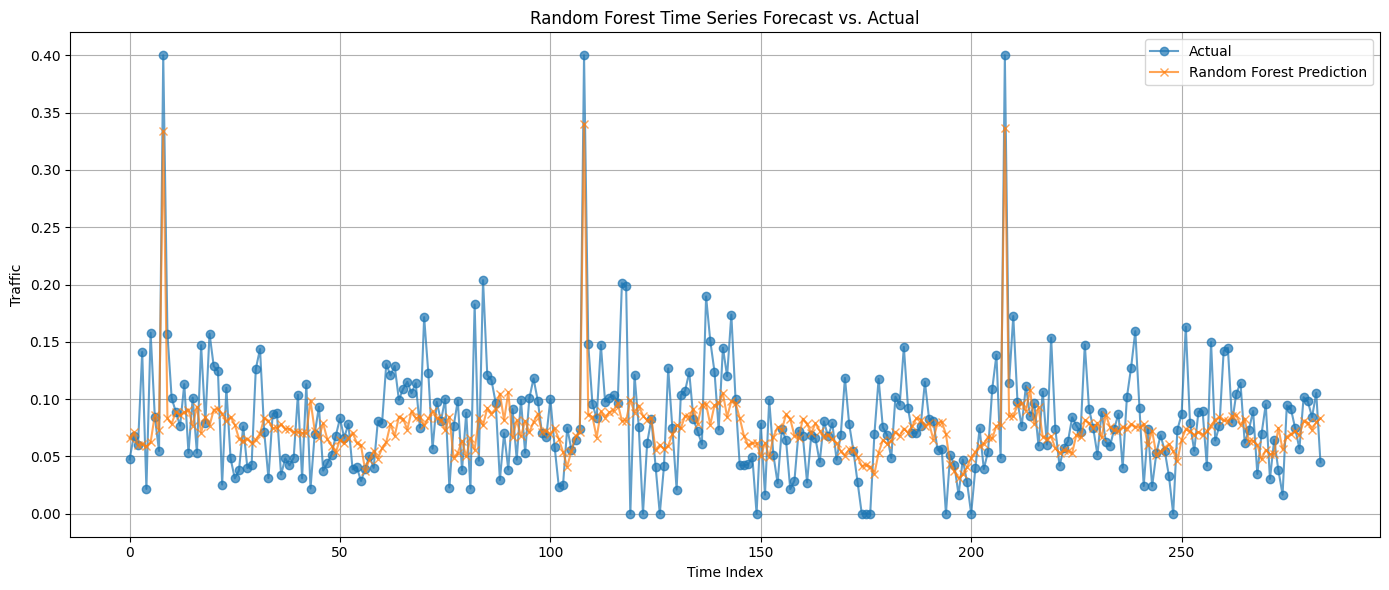

In [ ]:
# RandomForestRegressor 하이퍼 파라미터 이후 최적 피처값

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
best_rmse = 1
for i in range(6):
    for j in range(6):
        # window size
        X, y = make_features_with_time(only_slided_series, window=24, prev100_n=i, samehour_n=j)

        # 데이터 분리 (예: 80% 학습, 20% 테스트)
        split = -284
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # 모델 학습
        model = RandomForestRegressor(max_depth = None,
                                      max_features = 'sqrt', min_samples_leaf = 1,
                                      min_samples_split = 7, n_estimators = 379, random_state=42)
        model.fit(X_train, y_train)

        # 예측 및 평가
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        if best_rmse > rmse:
            best_rmse = rmse
            best_i = i
            best_j = j
            best_ypred = y_pred
print(best_rmse)
print(best_i)
print(best_j)

print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(best_ypred, label="Random Forest Prediction", marker='x', alpha=0.7)
plt.title("Random Forest Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')
/tmp/ipython-input-11-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead

0.039981514131817435
3
4
Test MSE: 0.0018680074298201984
Test RMSE: 0.04322045152263218


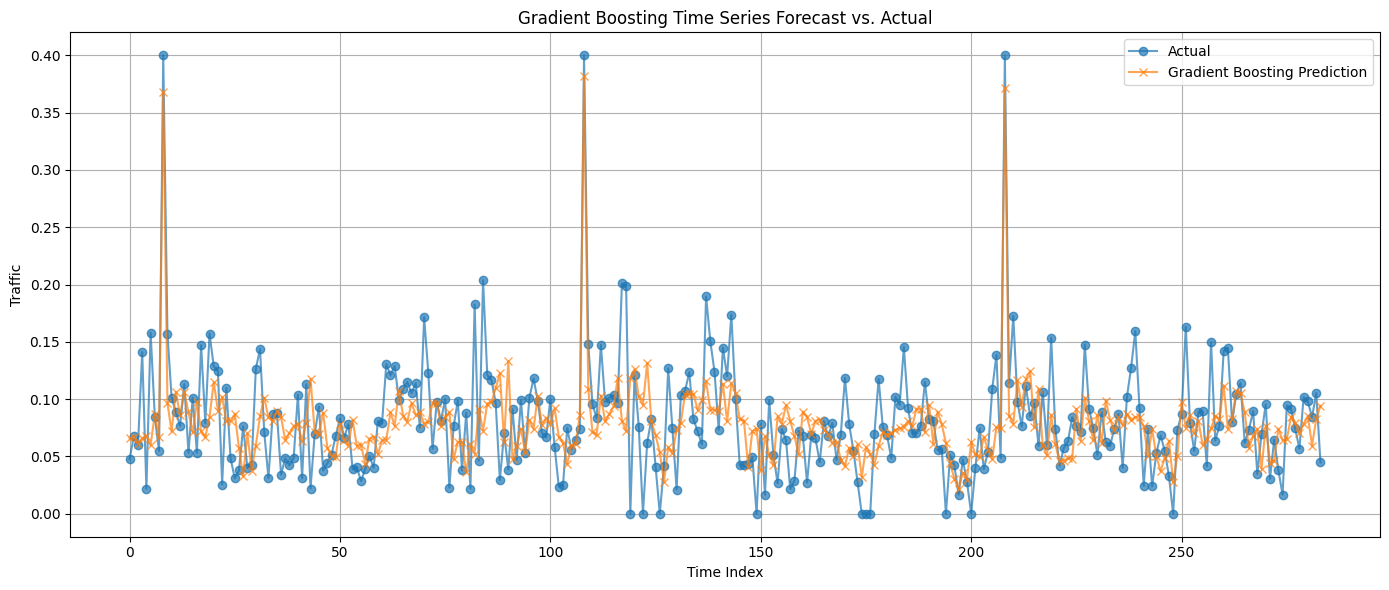

In [ ]:
# GradientBoosting Regressor 하이퍼 파라미터 이후 최적 피처값
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
best_rmse = 1
for i in range(6):
    for j in range(6):
        # window size
        X, y = make_features_with_time(only_slided_series, window=24, prev100_n=i, samehour_n=j)

        # 데이터 분리 (예: 80% 학습, 20% 테스트)
        split = -284
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # 모델 학습
        model = GradientBoostingRegressor(random_state=42, learning_rate = np.float64(0.03944488920695857), max_depth = 3, max_features = None, min_samples_leaf = 1, min_samples_split = 4, n_estimators = 227, subsample = np.float64(0.8118060601282148))
        model.fit(X_train, y_train)

        # 예측 및 평가
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        if best_rmse > rmse:
            best_rmse = rmse
            best_i = i
            best_j = j
            best_ypred = y_pred
print(best_rmse)
print(best_i)
print(best_j)


print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(best_ypred, label="Gradient Boosting Prediction", marker='x', alpha=0.7)
plt.title("Gradient Boosting Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#초반구간 가중치 부여 및 추가

/tmp/ipython-input-4-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0015623399397987371
Test RMSE: 0.03952644608105739


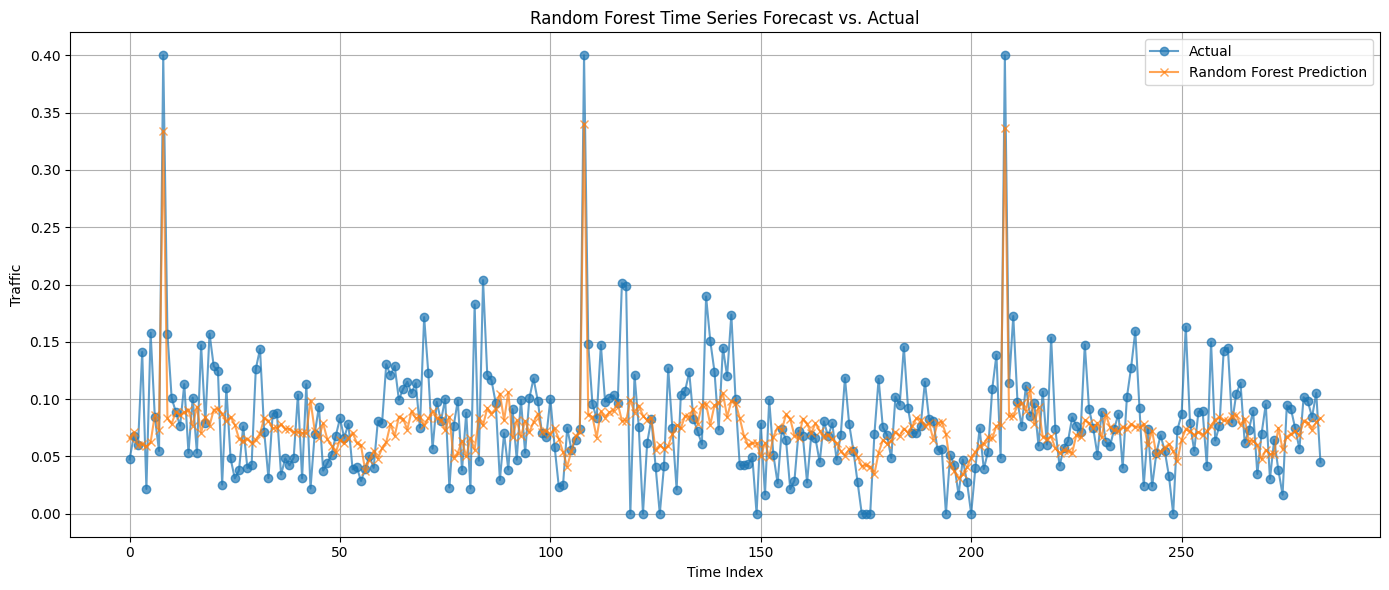

In [ ]:
# RandomForestRegressor를 이용한 테스트 코드, 가중치 x

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=3, samehour_n=0)

# 데이터 분리 (80% 학습, 20% 테스트)
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습
model = RandomForestRegressor(max_depth = None, max_features = 'sqrt', min_samples_leaf = 1, min_samples_split = 7, n_estimators = 379, random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Random Forest Prediction", marker='x', alpha=0.7)
plt.title("Random Forest Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-7-957063332>:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0016524428172663469
Test RMSE: 0.04065024990410695


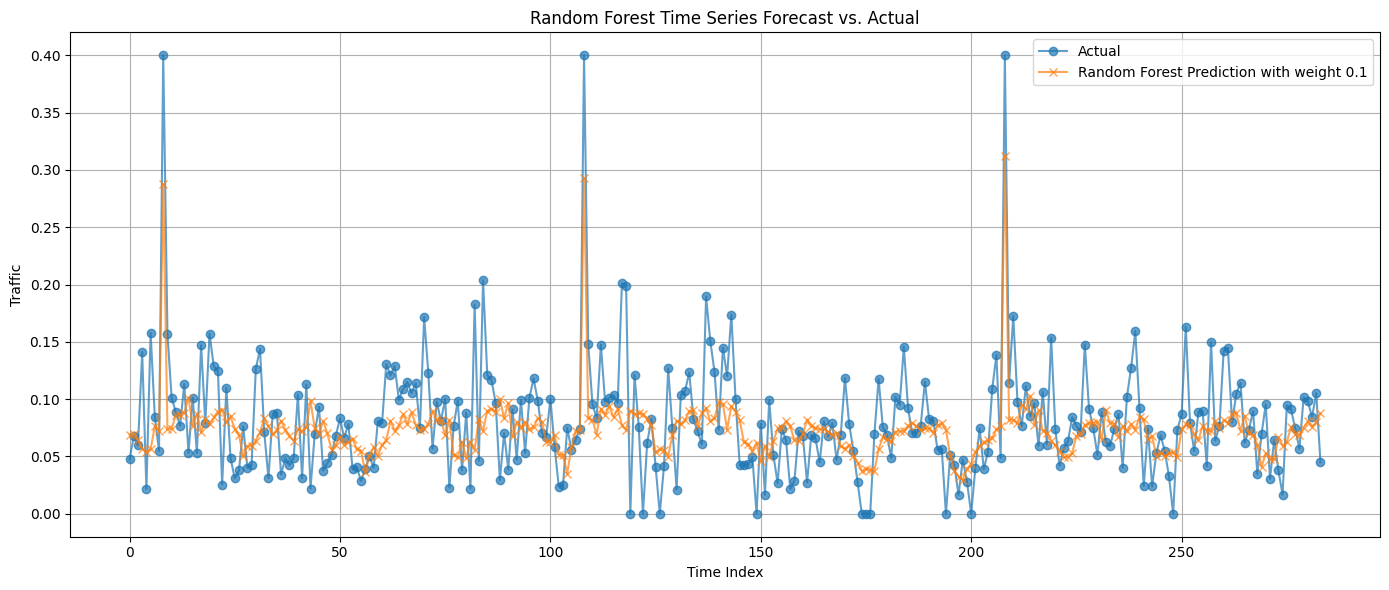

In [ ]:
# RandomForestRegressor를 이용한 테스트 코드, 가중치 0.1

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(series, window=24, prev100_n=3, samehour_n=0)

# 데이터 분리 (초반 264개 없는 기준 80% 학습, 20% 테스트)
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 초반 구간(과하게 높은) 가중치 조정
weights = np.ones_like(y_train)
weights[y_train < 264] = 0.1 #초반 264구간 가중치 0.1

# 모델 학습
model = RandomForestRegressor(max_depth = None, max_features = 'sqrt', min_samples_leaf = 1, min_samples_split = 7, n_estimators = 379, random_state=42)
model.fit(X_train, y_train, sample_weight = weights)

# 예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Random Forest Prediction with weight 0.1", marker='x', alpha=0.7)
plt.title("Random Forest Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4-1198210109.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0015985214722727173
Test RMSE: 0.039981514131817435


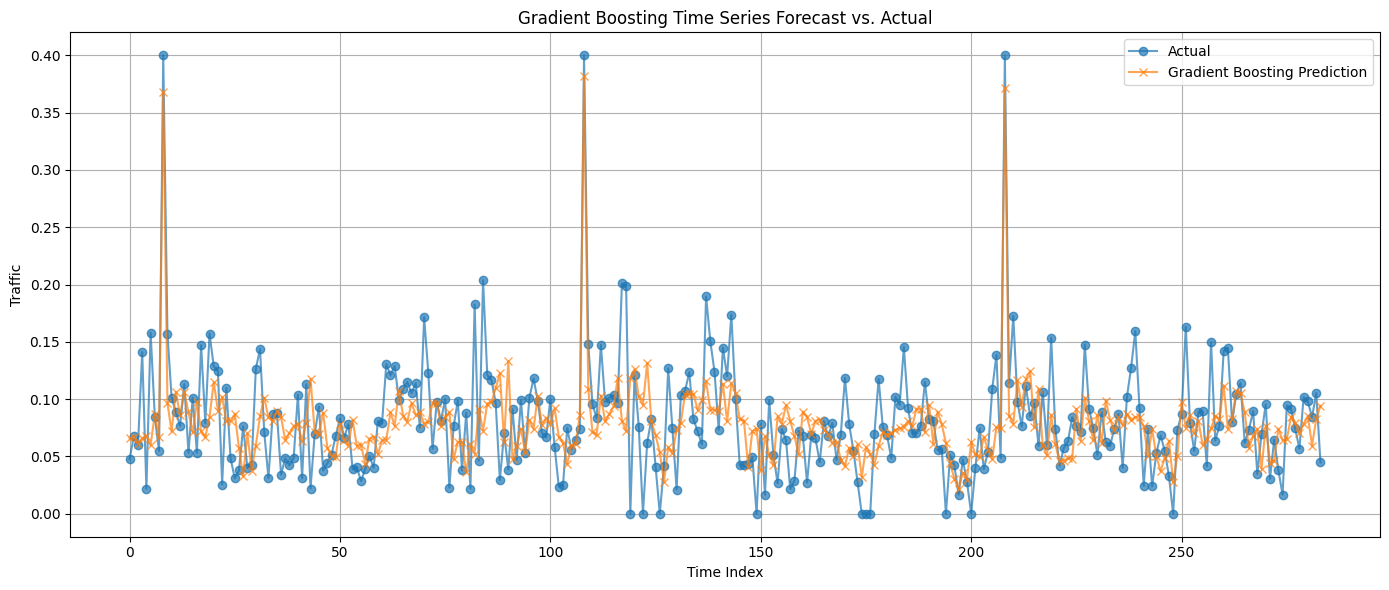

In [ ]:
# GradientBoosting Regressor을 이용한 테스트, 가중치 x
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(only_slided_series, window=24, prev100_n=3, samehour_n=4)

# 학습/테스트 분할
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 모델 학습 및 예측
model = GradientBoostingRegressor(random_state=42, learning_rate = np.float64(0.03944488920695857), max_depth = 3, max_features = None, min_samples_leaf = 1, min_samples_split = 4, n_estimators = 227, subsample = np.float64(0.8118060601282148))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 성능 평가 (MSE, RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Gradient Boosting Prediction", marker='x', alpha=0.7)
plt.title("Gradient Boosting Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-7-957063332>:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=len(series), freq='H')


Test MSE: 0.0017498516573743567
Test RMSE: 0.04183122825562688


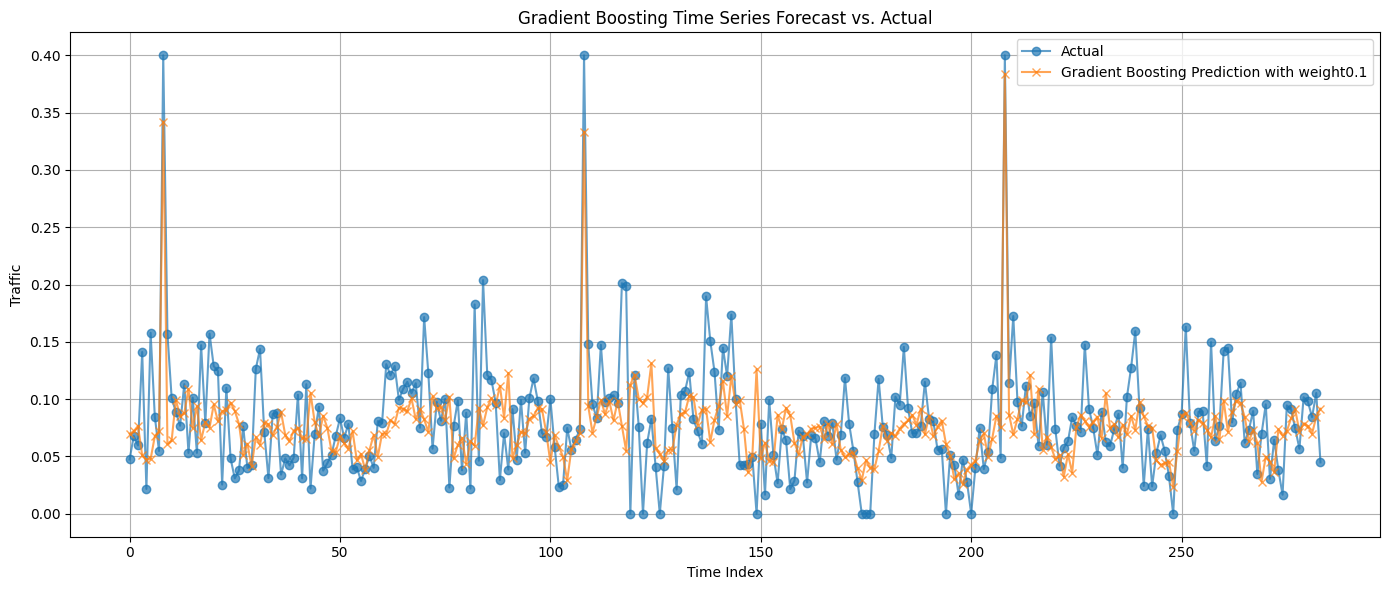

In [ ]:
# GradientBoosting Regressor을 이용한 테스트, 초반구간 추가 후 가중치 0.1

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# window size
X, y = make_features_with_time(series, window=24, prev100_n=3, samehour_n=4)

# 데이터 분리
split = -284
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 초반 구간(과하게 높은) 가중치 조정
weights = np.ones_like(y_train)
weights[y_train < 264] = 0.1 #초반 264구간 가중치 0.1

# 모델 학습 및 예측
model = GradientBoostingRegressor(random_state=42, learning_rate = np.float64(0.03944488920695857), max_depth = 3, max_features = None, min_samples_leaf = 1, min_samples_split = 4, n_estimators = 227, subsample = np.float64(0.8118060601282148))
model.fit(X_train, y_train, sample_weight = weights)
y_pred = model.predict(X_test)

# 성능 평가 (MSE, RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

#시각화
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred, label="Gradient Boosting Prediction with weight0.1", marker='x', alpha=0.7)
plt.title("Gradient Boosting Time Series Forecast vs. Actual")
plt.xlabel("Time Index")
plt.ylabel("Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()